In [35]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import umap.umap_ as umap
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Base_Videos_Final.csv")
df.head()

C:\Users\crist\AppData\Local\Temp\ipykernel_20736\2037441679.py:1: DtypeWarning: Columns (6,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Base_Videos_Final.csv")


,frame_idx,duration,total_frames,video_duration,player_id,player_name,team,zone,ball_position_x,ball_position_y,...,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,time_since_last_hit,partido,punto
0,0,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
1,1,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
2,2,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
3,3,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
4,4,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0


In [3]:
df.partido.drop_duplicates()

0         Partido 27
23839     Partido 29
43205     Partido 35
59801              1
63395             11
65536             11
89332             13
112671            15
144563            17
163981            19
180236            21
200221            23
208966             3
221981            31
234271            37
249578            41
258740             9
294912             9
321377    Partido 22
339621    Partido 28
357362    Partido 30
378238    partido 40
385013            12
393216            12
404118            14
419943            18
441248            20
459415            32
468362            34
482494            36
497716            38
511161             4
516126            42
522162            44
527784             6
531907             8
Name: partido, dtype: object

In [4]:
df.columns

Index(['frame_idx', 'duration', 'total_frames', 'video_duration', 'player_id',
       'player_name', 'team', 'zone', 'ball_position_x', 'ball_position_y',
       'player_position_x', 'player_position_y', 'distance_ball_to_net',
       'distance_player_to_ball_m', 'distance_player_to_net_m',
       'distance_player_to_teammate_m', 'player_hits_ball', 'prev_x', 'prev_y',
       'player_displacement', 'player_speed_mps', 'prev_speed',
       'player_acceleration_mps2', 'ball_position_x_prev',
       'ball_position_y_prev', 'ball_displacement', 'ball_speed_mps',
       'time_since_last_hit', 'partido', 'punto'],
      dtype='object')

In [5]:
print("Tipo de columnas:", df.dtypes)
print("-------------------------------")
print("Valores nulos:", df.isnull().sum())
print("-------------------------------")
print("Filas duplicadas:", df.duplicated().sum())

Tipo de columnas: frame_idx                          int64
duration                         float64
total_frames                       int64
video_duration                   float64
player_id                          int64
player_name                       object
team                              object
zone                              object
ball_position_x                  float64
ball_position_y                  float64
player_position_x                float64
player_position_y                float64
distance_ball_to_net             float64
distance_player_to_ball_m        float64
distance_player_to_net_m         float64
distance_player_to_teammate_m    float64
player_hits_ball                    bool
prev_x                           float64
prev_y                           float64
player_displacement              float64
player_speed_mps                 float64
prev_speed                       float64
player_acceleration_mps2         float64
ball_position_x_prev             float6

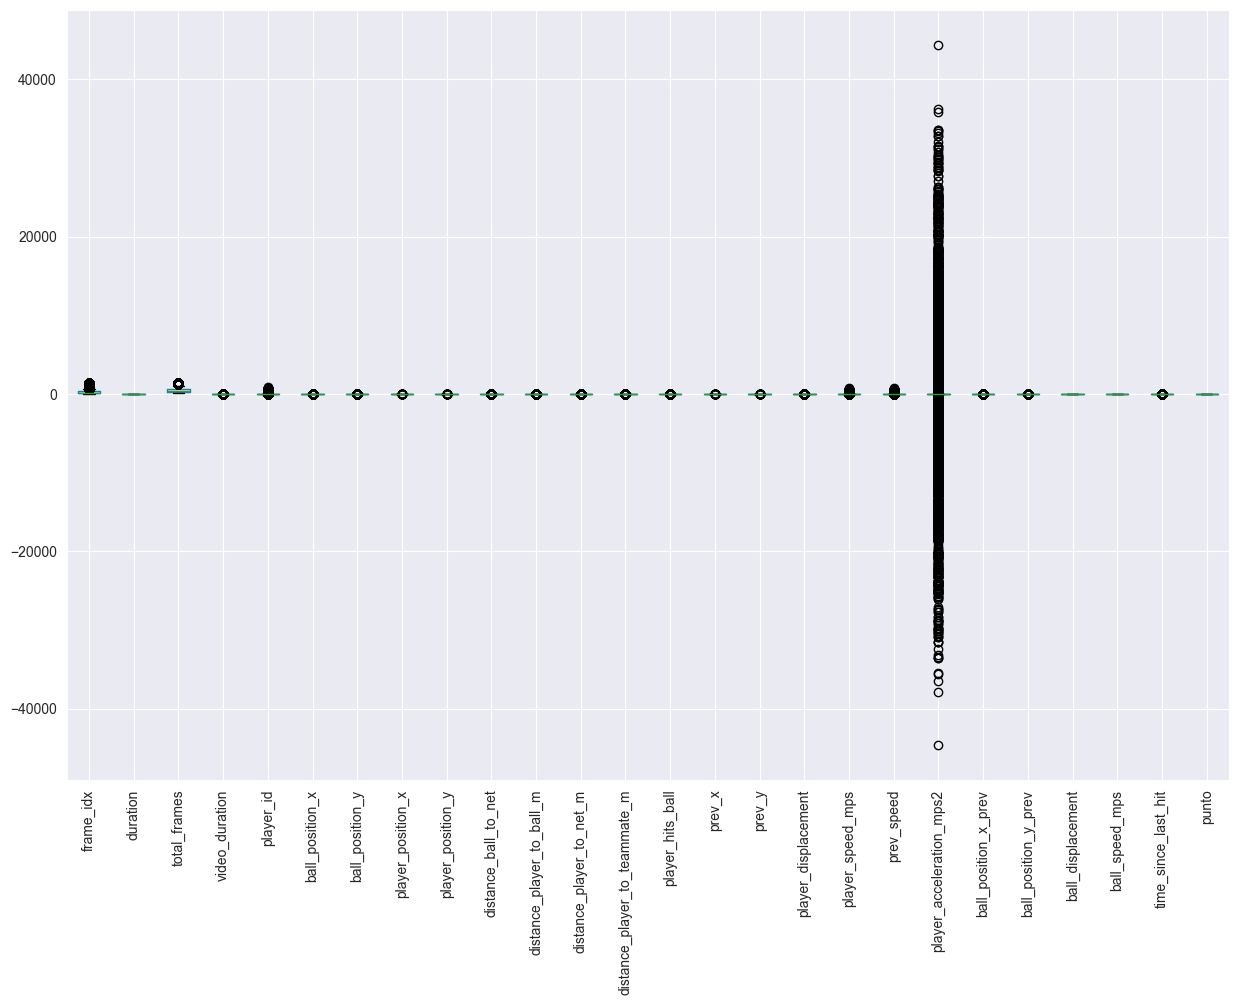

In [6]:
df.boxplot(figsize=(15,10))
plt.xticks(rotation=90)
plt.show()


In [7]:
df1 = pd.read_csv("Base_Videos_Final.csv")

C:\Users\crist\AppData\Local\Temp\ipykernel_20736\3201232489.py:1: DtypeWarning: Columns (6,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("Base_Videos_Final.csv")


In [8]:
cols_to_drop = [
    'player_name', 'partido', 'punto',
    'frame_idx', 'duration', 'total_frames', 'video_duration',
    'prev_x', 'prev_y',
    'ball_position_x_prev', 'ball_position_y_prev',
    'time_since_last_hit'
]

In [9]:
df1 = df.drop(columns=cols_to_drop)
df1.head()

,player_id,team,zone,ball_position_x,ball_position_y,player_position_x,player_position_y,distance_ball_to_net,distance_player_to_ball_m,distance_player_to_net_m,distance_player_to_teammate_m,player_hits_ball,player_displacement,player_speed_mps,prev_speed,player_acceleration_mps2,ball_displacement,ball_speed_mps
0,1,top,right_box,3.24,17.111111,1.48,1.48,7.111111,13.58119,6.355556,7.41199,False,NaN,NaN,NaN,NaN,NaN,NaN
1,1,top,right_box,3.24,17.111111,1.48,1.48,7.111111,13.58119,6.355556,7.41199,False,0.0,0.0,NaN,NaN,NaN,NaN
2,1,top,right_box,3.24,17.111111,1.48,1.48,7.111111,13.58119,6.355556,7.41199,False,0.0,0.0,0.0,0.0,NaN,NaN
3,1,top,right_box,3.24,17.111111,1.48,1.48,7.111111,13.58119,6.355556,7.38810,False,0.0,0.0,0.0,0.0,NaN,NaN
4,1,top,right_box,3.24,17.111111,1.48,1.48,7.111111,13.58119,6.355556,7.38810,False,0.0,0.0,0.0,0.0,NaN,NaN


In [10]:
cat_cols = ['team', 'zone']
num_cols = df1.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

In [11]:
for col in num_cols:
    df1[col] = df1[col].fillna(df1[col].median())


In [12]:
for col in cat_cols:
    df1[col] = df1[col].fillna('Unknown')

In [13]:
df2 = pd.get_dummies(df1, columns=cat_cols, drop_first=True)

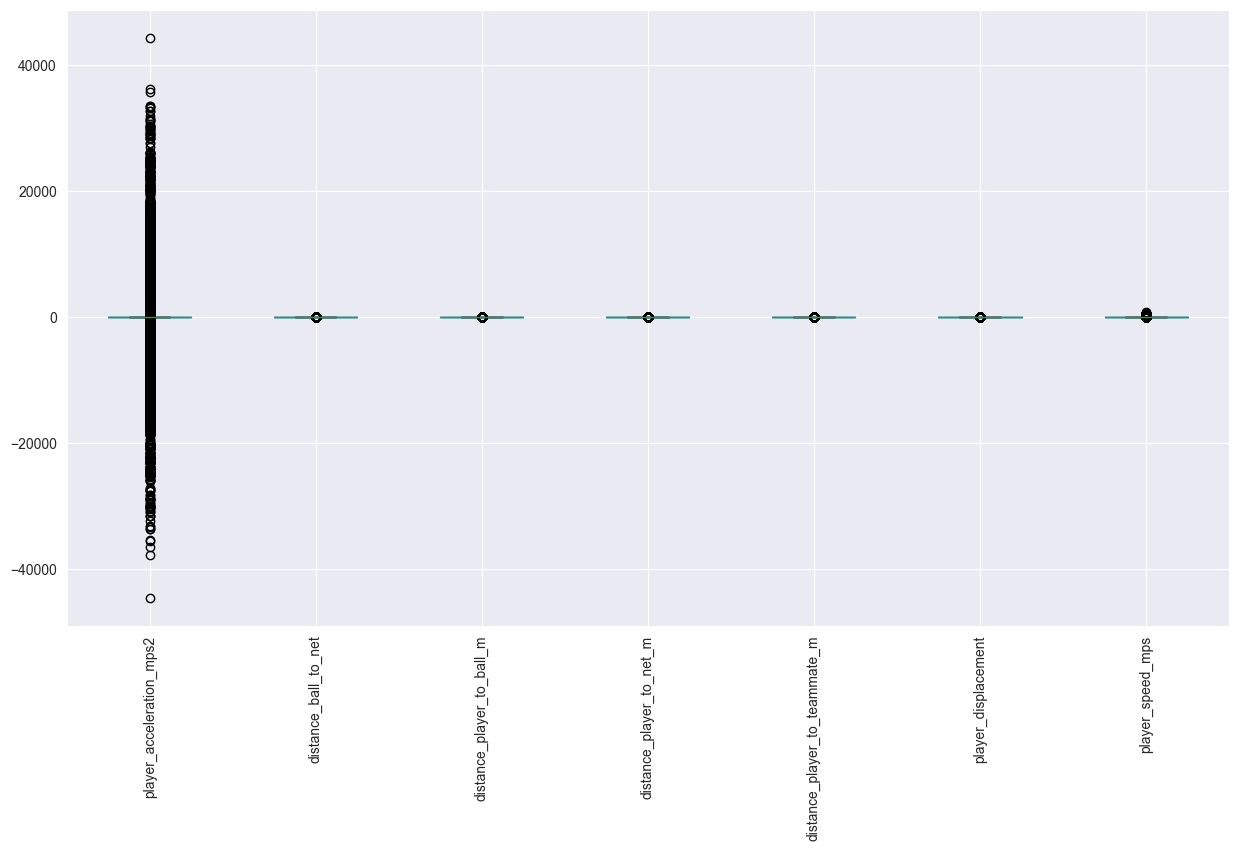

In [14]:
num_cols_continuas = [
    'player_acceleration_mps2', 'distance_ball_to_net', 'distance_player_to_ball_m',
    'distance_player_to_net_m', 'distance_player_to_teammate_m',
    'player_displacement', 'player_speed_mps'
]
df2[num_cols_continuas].boxplot(figsize=(15,8))
plt.xticks(rotation=90)
plt.show()

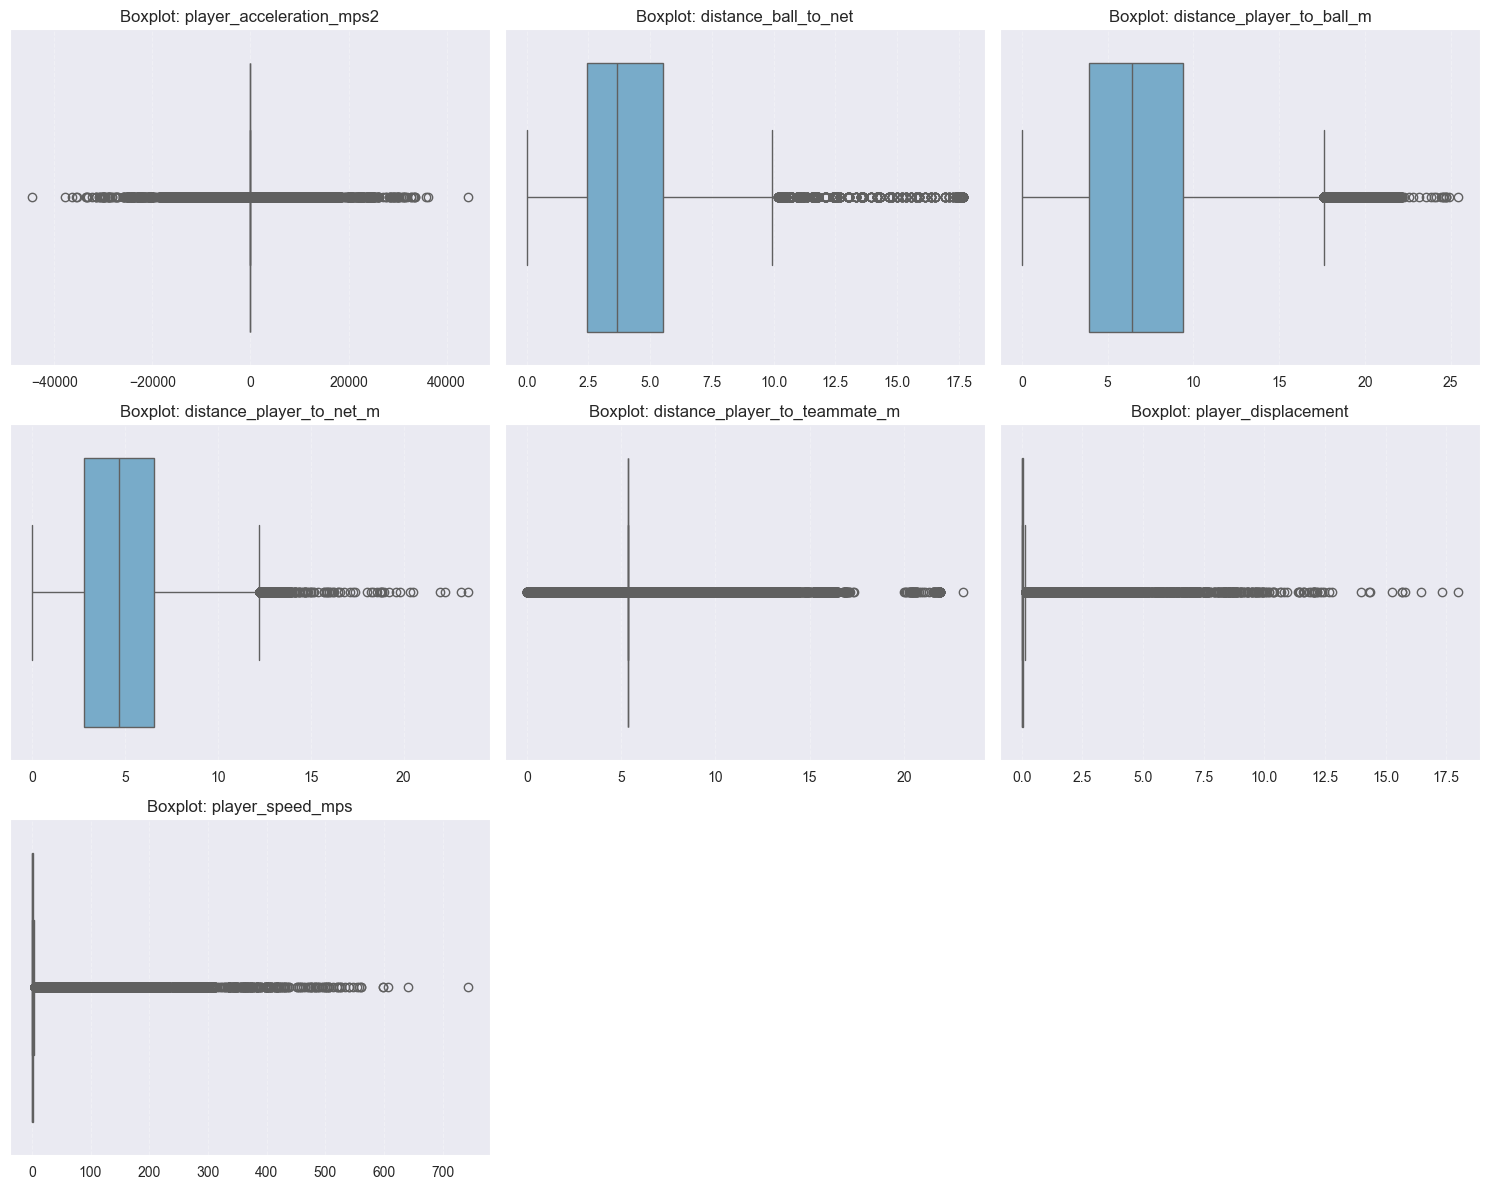

In [15]:

num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(15, 12))

for i, col in enumerate(num_cols_continuas):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df2[col], color="#6BAED6")
    plt.title(f"Boxplot: {col}", fontsize=12)
    plt.xlabel("")  # para que no repita nombre abajo
    plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
df2 = df2[df2['player_speed_mps'].between(0, 9)]
df2 = df2[df2['player_acceleration_mps2'].between(-10, 10)]

df2 = df2.reset_index(drop=True)

x = df2[num_cols_continuas].copy()

In [17]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

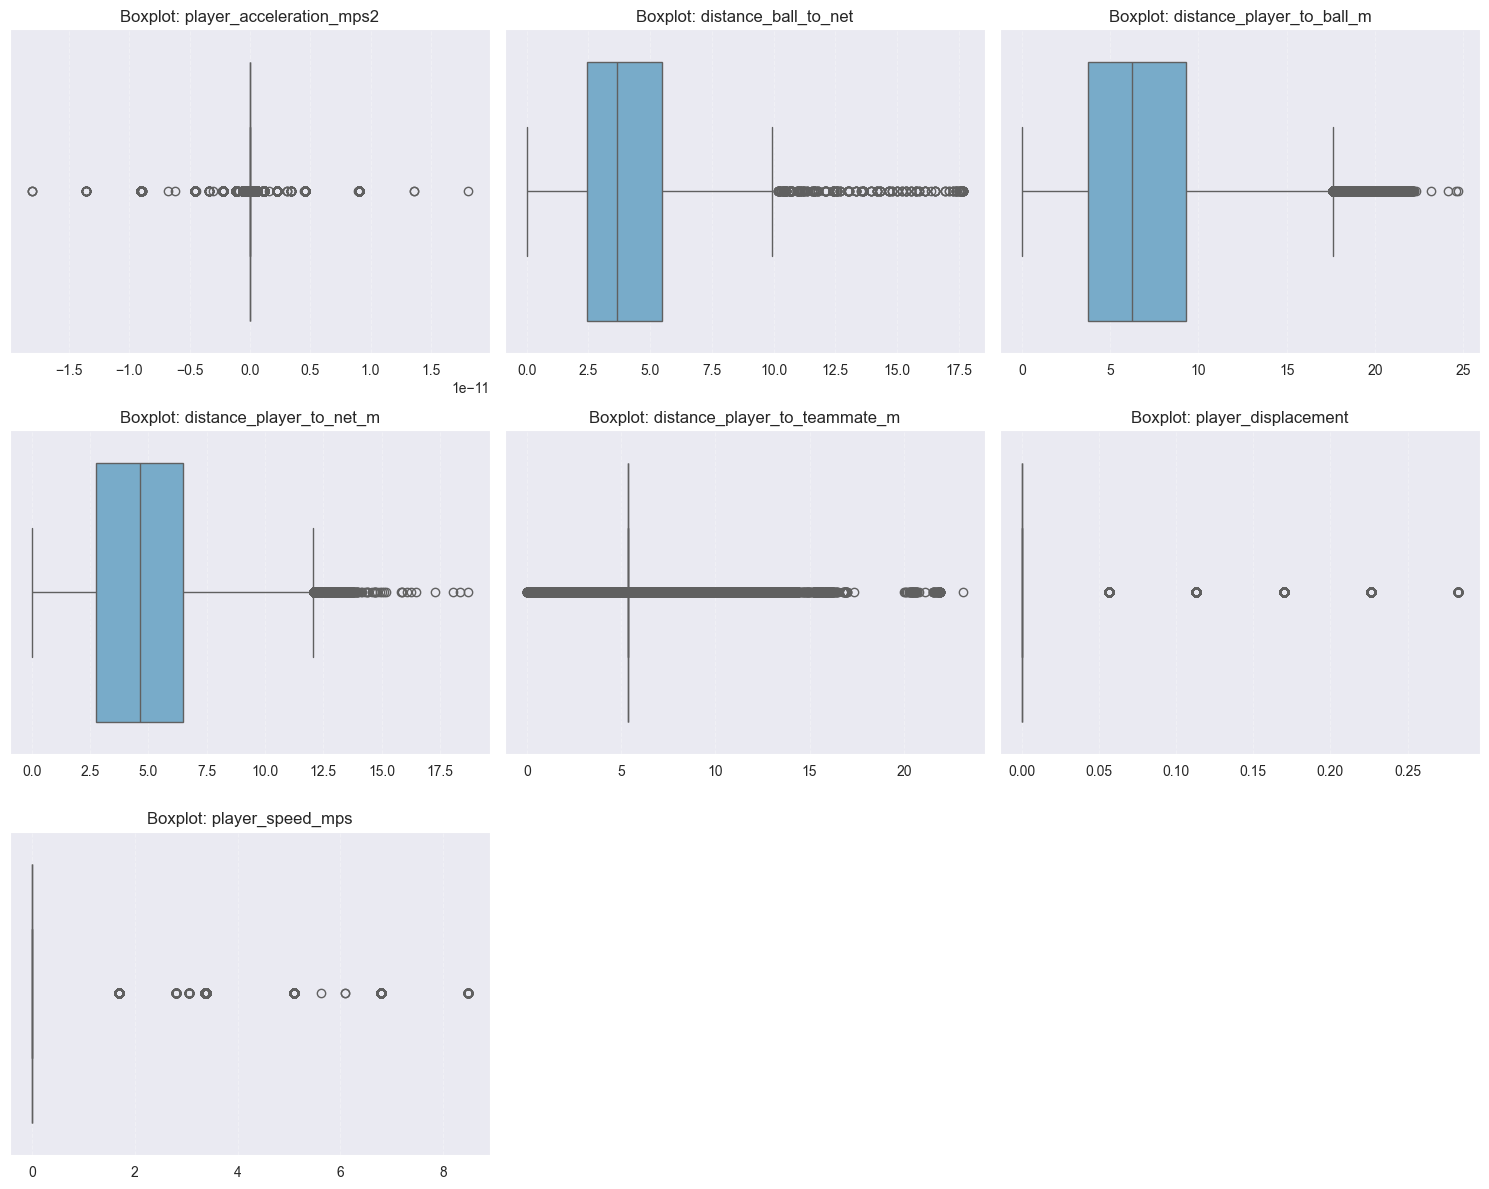

In [18]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(num_cols_continuas):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df2[col], color="#6BAED6")
    plt.title(f"Boxplot: {col}", fontsize=12)
    plt.xlabel("")  # para que no repita nombre abajo
    plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
df2[num_cols_continuas].describe().T[['min','max']]
#Las variables NO tienen outliers absurdos
#El efecto extraño fue causado por el escalado + columnas categóricas
#El dataset está apto para clustering
#Solo falta graficar bien las variables continuas


,min,max
player_acceleration_mps2,-1.809219e-11,1.809219e-11
distance_ball_to_net,0.000000e+00,1.768889e+01
distance_player_to_ball_m,0.000000e+00,2.470293e+01
distance_player_to_net_m,0.000000e+00,1.871111e+01
distance_player_to_teammate_m,0.000000e+00,2.314716e+01
player_displacement,0.000000e+00,2.828427e-01
player_speed_mps,0.000000e+00,8.485281e+00


In [44]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])

In [45]:
df_agg = df2.groupby("player_id")[num_cols_continuas].mean().reset_index()

x = df_agg[num_cols_continuas]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
)


umap_coords = umap_model.fit_transform(x_scaled)

umap_df = pd.DataFrame(umap_coords, columns=['UMAP1', 'UMAP2'])

C:\Users\crist\Documents\Crist\ProyectosCRIS\ProyectofinAnalitica\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


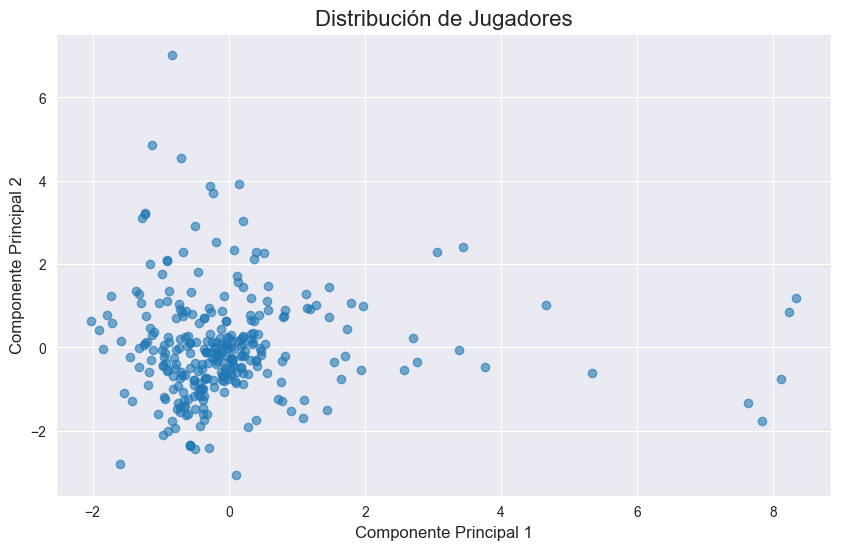

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)
plt.title('Distribución de Jugadores', fontsize=16)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(True)
plt.show()

In [47]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(x_scaled)

df2['cluster'] = clusters
pca_df['cluster'] = clusters

ValueError: Length of values (300) does not match length of index (355168)

In [48]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(umap_df)

umap_df["cluster"] = clusters
df_agg["cluster"] = clusters

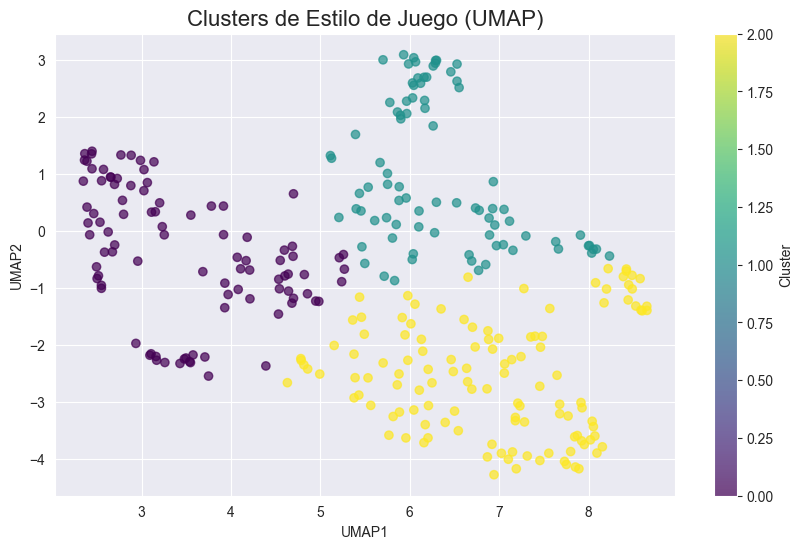

In [49]:
plt.figure(figsize=(10,6))
plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], c=clusters, cmap='viridis', alpha=0.7)
plt.title("Clusters de Estilo de Juego (UMAP)", fontsize=16)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [36]:

sil_score = silhouette_score(x_scaled, clusters)

print(f"Silhouette Score del modelo = {sil_score:.4f}")

Silhouette Score del modelo = 0.1116


In [53]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean'
)

clusters_hdb = clusterer.fit_predict(umap_df)

df_agg["cluster_hdb"] = clusters_hdb

print(df_agg.head())

   player_id  player_acceleration_mps2  distance_ball_to_net  \
0          1             -2.213354e-15              3.904162   
1          2             -1.058367e-15              3.978143   
2          3             -5.240772e-17              3.821759   
3          4             -1.473666e-15              3.902662   
4          5             -1.045491e-14              4.150903   

   distance_player_to_ball_m  distance_player_to_net_m  \
0                   6.669719                  4.805605   
1                   6.659846                  4.372892   
2                   5.984921                  4.491739   
3                   6.922875                  4.960776   
4                   7.302634                  4.765332   

   distance_player_to_teammate_m  player_displacement  player_speed_mps  \
0                       5.551094             0.005888          0.231697   
1                       5.437018             0.006540          0.263204   
2                       5.314619         

C:\Users\crist\Documents\Crist\ProyectosCRIS\ProyectofinAnalitica\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\crist\Documents\Crist\ProyectosCRIS\ProyectofinAnalitica\.venv\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


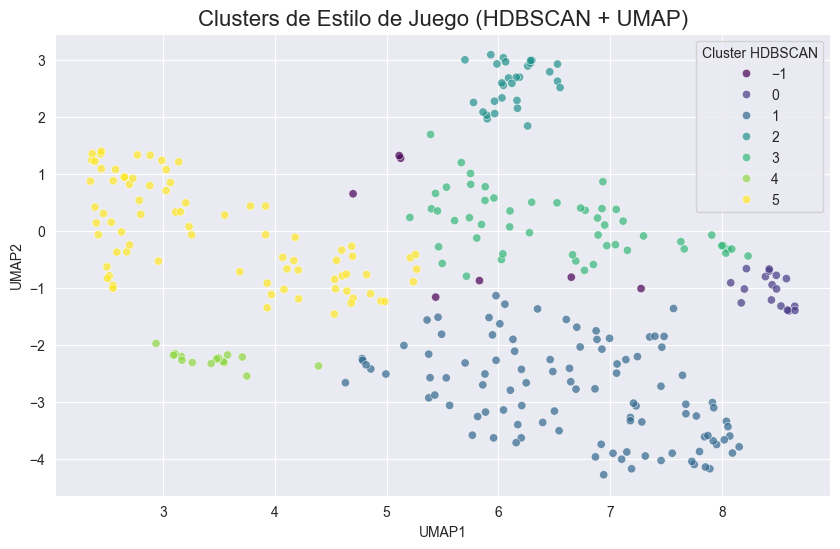

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=umap_df['UMAP1'],
    y=umap_df['UMAP2'],
    hue=df_agg['cluster_hdb'],
    palette='viridis',
    alpha=0.7
)

plt.title('Clusters de Estilo de Juego (HDBSCAN + UMAP)', fontsize=16)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(title="Cluster HDBSCAN")
plt.grid(True)
plt.show()

# 📌 Tabla 1 — Interpretación por Cluster (HDBSCAN)

| **Cluster HDBSCAN** | **Características** | **Comportamiento** | **Interpretación** |
|---------------------|--------------------|---------------------|---------------------|
| **-1** | Puntos sin patrón claro. Baja densidad. | Atípicos o ruido. | No considerar para estilo. Revisar individualmente. |
| **0** | Movilidad baja, ritmo pausado, desplazamientos controlados. | Conservador, espera el error del rival. | **Defensivo** |
| **1** | Movilidad media, ritmos estables, decisiones equilibradas. | Control del punto, transición ordenada defensa-ataque. | **Normal / Balanceado** |
| **2** | Movilidad media-alta, acercamiento frecuente a zona ofensiva. | Agresivo técnico, juega con intención ofensiva moderada. | **Agresivo** |
| **3** | Movilidad alta, dispersión grande, ritmo rápido. | Muy ofensivo, busca winners y arriesga constantemente. | **Agresivo extremo** |
| **4** | Movilidad defensiva rápida, recuperaciones amplias, orden táctico. | Defensa organizada con contraataque. | **Defensivo táctico** |
| **5** | Movilidad muy alta y caótica, cambios bruscos. | Híper-agresivo, decisiones menos controladas. | **Ultra-agresivo** |


In [56]:
interpreta_estilo = {
    -1: "Ruido / No considerar",
     0: "Defensivo",
     1: "Normal / Balanceado",
     2: "Agresivo",
     3: "Agresivo extremo",
     4: "Defensivo táctico",
     5: "Ultra-agresivo"
}

In [60]:
df_agg = df2.groupby("player_id")[num_cols_continuas].mean().reset_index()
df_agg["player_name"] = df2.groupby("player_id")["player_name"].first().values

df_agg["cluster_hdb"] = clusters_hdb

df_agg["estilo_juego"] = df_agg["cluster_hdb"].map(interpreta_estilo)

tabla_estilos = df_agg[["player_id", "player_name", "cluster_hdb", "estilo_juego"]]
tabla_estilos.head(100)


,player_id,player_name,cluster_hdb,estilo_juego
0,1,Luis Jorge Garcia Camargo,5,Ultra-agresivo
1,2,Luis Jorge Garcia Camargo,5,Ultra-agresivo
2,3,Nicole Lizarazo,5,Ultra-agresivo
3,4,Nikol sofia avendaño,5,Ultra-agresivo
4,5,Valentina Alejandra Lopez Romero,5,Ultra-agresivo
...,...,...,...,...
95,98,Player_4,5,Ultra-agresivo
96,99,Luis Jorge Garcia Camargo,5,Ultra-agresivo
97,100,Nicole Lizarazo,3,Agresivo extremo
98,101,Andrea Julieth Sosa Rodriguez,1,Normal / Balanceado


In [61]:
mask = clusters_hdb != -1
X_valid = umap_df[mask]
labels_valid = clusters_hdb[mask]

sil_hdb = silhouette_score(X_valid, labels_valid)
sil_hdb

0.5173787216609969

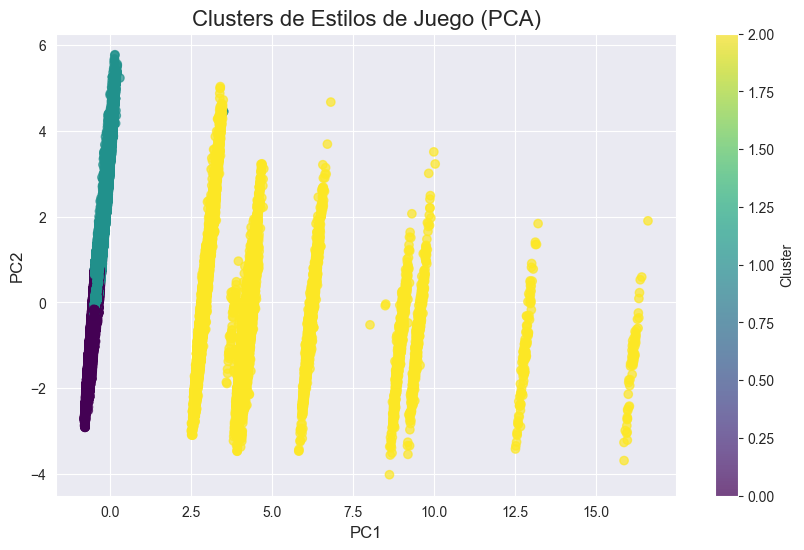

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['cluster'], cmap='viridis', alpha=0.7)
plt.title('Clusters de Estilos de Juego (PCA)', fontsize=16)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


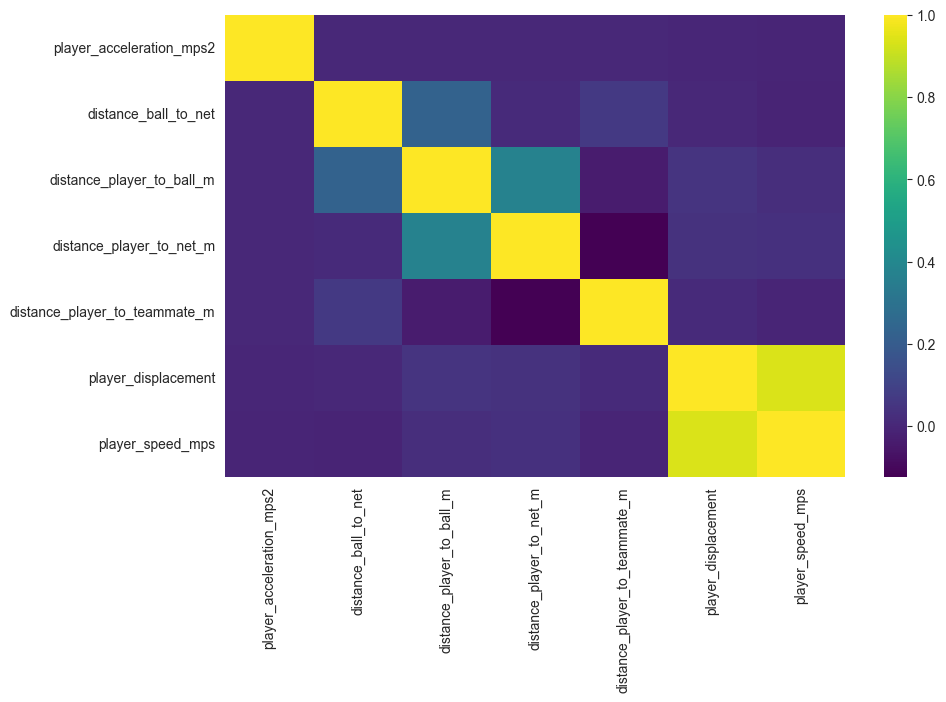

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(x.corr(), annot=False, cmap="viridis")
plt.show()

In [27]:
#Morado jugadores mas tranquilos o defensivos, Azul aguamarina es moderado, amarillo agresivo, muy disperso.

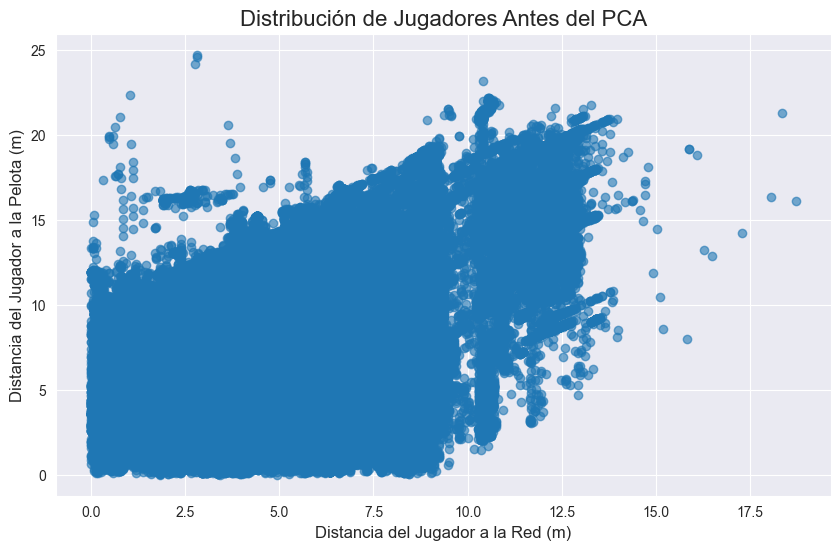

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df2['distance_player_to_net_m'],
    df2['distance_player_to_ball_m'],
    alpha=0.6
)

plt.title('Distribución de Jugadores Antes del PCA', fontsize=16)
plt.xlabel('Distancia del Jugador a la Red (m)', fontsize=12)
plt.ylabel('Distancia del Jugador a la Pelota (m)', fontsize=12)
plt.grid(True)
plt.show()
